# Learning Curve

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [3]:
# set path
json_path = './models/esm2_8m_base-sft/encoder_lr_5e-5_batch_size_16_encoder_weight_decay_0.0001/checkpoints/checkpoint-1450/trainer_state.json'

# load json file
with open(json_path, 'r') as f:
    trainer_state = json.load(f)

# check if file exists
if Path(json_path).exists():
    print(f"file exists. {json_path} is loaded.")
else:
    print(f"error: {json_path} not found.")
    print("please specify the correct path.")

file exists. ./models/esm2_8m_base-sft/encoder_lr_5e-5_batch_size_16_encoder_weight_decay_0.0001/checkpoints/checkpoint-1450/trainer_state.json is loaded.


In [4]:
# extract training and evaluation data
log_history = trainer_state['log_history']

# training data (step-by-step)
train_steps, train_losses, train_grad_norms, train_lrs = [], [], [], []

# evaluation data (step-by-step)
eval_steps, eval_losses, eval_mae, eval_mse, eval_r2, eval_rmse = [], [], [], [], [], []

for entry in log_history:
    step = entry['step']
    
    # extract training data
    if 'loss' in entry:
        train_steps.append(step)
        train_losses.append(entry['loss'])
        train_grad_norms.append(entry.get('grad_norm', 0))
        train_lrs.append(entry.get('learning_rate', 0))
    
    # extract evaluation data
    if 'eval_loss' in entry:
        eval_steps.append(step)
        eval_losses.append(entry['eval_loss'])
        eval_mae.append(entry.get('eval_mae', 0))
        eval_mse.append(entry.get('eval_mse', 0))
        eval_r2.append(entry.get('eval_r2', 0))
        eval_rmse.append(entry.get('eval_rmse', 0))

data = {
    'train': {
        'steps': train_steps,
        'losses': train_losses,
        'grad_norms': train_grad_norms,
        'learning_rates': train_lrs
    },
    'eval': {
        'steps': eval_steps,
        'losses': eval_losses,
        'mae': eval_mae,
        'mse': eval_mse,
        'r2': eval_r2,
        'rmse': eval_rmse
    }
}

print(f"training data number: {len(data['train']['steps'])}")
print(f"evaluation data number: {len(data['eval']['steps'])}")

print("=== statistics ===")
if data['train']['losses']:
    print(f"training loss - min: {min(data['train']['losses']):.4f}, max: {max(data['train']['losses']):.4f}")
if data['eval']['losses']:
    print(f"evaluation loss - min: {min(data['eval']['losses']):.4f}, max: {max(data['eval']['losses']):.4f}")

training data number: 50
evaluation data number: 50
=== statistics ===
training loss - min: 1.3301, max: 4359.7185
evaluation loss - min: 29.1306, max: 3438.5991


In [5]:
# display training summary
print("=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"Total epochs: {trainer_state['num_train_epochs']}")
print(f"Total steps: {trainer_state['global_step']}")
print(f"Best metric: {trainer_state['best_metric']}")
print(f"Best checkpoint: {trainer_state['best_model_checkpoint']}")
print(f"Train batch size: {trainer_state['train_batch_size']}")

# display evaluation summary (RMSE best)
print("\n" + "-" * 40)
print("BEST EVALUATION METRICS (RMSE)")
print("-" * 40)
if data['eval']['steps']:
    # get index of minimum RMSE
    best_rmse_idx = data['eval']['rmse'].index(min(data['eval']['rmse']))
    best_step = data['eval']['steps'][best_rmse_idx]
    best_loss = data['eval']['losses'][best_rmse_idx]
    best_mae = data['eval']['mae'][best_rmse_idx]
    best_rmse = data['eval']['rmse'][best_rmse_idx]
    best_r2 = data['eval']['r2'][best_rmse_idx]
    
    print(f"Best RMSE step: {best_step}")
    print(f"Best loss: {best_loss:.4f}")
    print(f"Best MAE: {best_mae:.4f}")
    print(f"Best RMSE: {best_rmse:.4f}")
    print(f"Best R²: {best_r2:.4f}")

print("\n" + "-" * 40)
print("TRAINING PROGRESS")
print("-" * 40)
if data['train']['steps']:
    initial_loss = data['train']['losses'][0]
    final_train_loss = data['train']['losses'][-1]
    loss_reduction = ((initial_loss - final_train_loss) / initial_loss) * 100
    
    print(f"Initial training loss: {initial_loss:.4f}")
    print(f"Final training loss: {final_train_loss:.4f}")
    print(f"Loss reduction: {loss_reduction:.2f}%")

TRAINING SUMMARY
Total epochs: 50
Total steps: 1450
Best metric: 29.13060188293457
Best checkpoint: models/20251130/esm2_8m_base-sft_mean_ridge_tempro-vhh_search/encoder_lr_5e-5_batch_size_16_encoder_weight_decay_0.0001/checkpoints/checkpoint-870
Train batch size: 16

----------------------------------------
BEST EVALUATION METRICS (RMSE)
----------------------------------------
Best RMSE step: 870
Best loss: 29.1306
Best MAE: 3.9286
Best RMSE: 5.3973
Best R²: 0.7398

----------------------------------------
TRAINING PROGRESS
----------------------------------------
Initial training loss: 4359.7185
Final training loss: 1.3301
Loss reduction: 99.97%


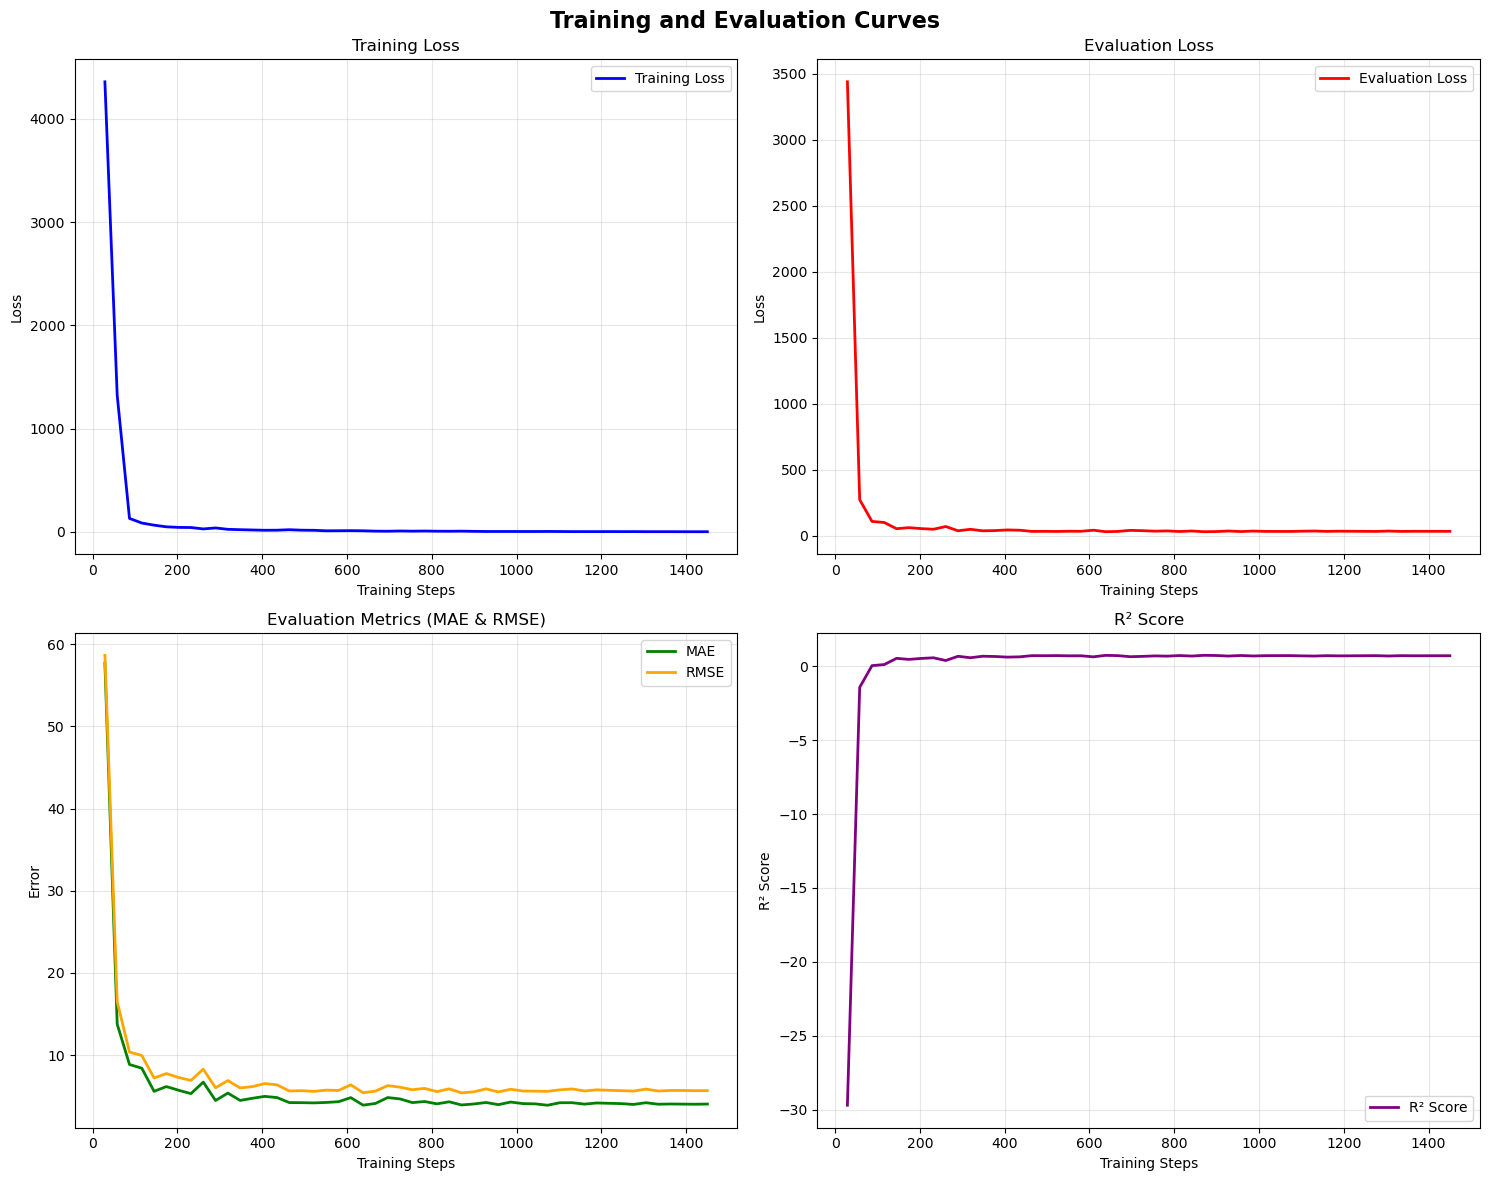

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Training and Evaluation Curves', fontsize=16, fontweight='bold')

# 1. training loss
ax1 = axes[0, 0]
ax1.plot(data['train']['steps'], data['train']['losses'], 'b-', linewidth=2, label='Training Loss')
ax1.set_xlabel('Training Steps')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. evaluation loss
ax2 = axes[0, 1]
ax2.plot(data['eval']['steps'], data['eval']['losses'], 'r-', linewidth=2, label='Evaluation Loss')
ax2.set_xlabel('Training Steps')
ax2.set_ylabel('Loss')
ax2.set_title('Evaluation Loss')
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3. evaluation metrics (MAE, RMSE)
ax3 = axes[1, 0]
ax3.plot(data['eval']['steps'], data['eval']['mae'], 'g-', linewidth=2, label='MAE')
ax3.plot(data['eval']['steps'], data['eval']['rmse'], 'orange', linewidth=2, label='RMSE')
ax3.set_xlabel('Training Steps')
ax3.set_ylabel('Error')
ax3.set_title('Evaluation Metrics (MAE & RMSE)')
ax3.grid(True, alpha=0.3)
ax3.legend()

# 4. R² score
ax4 = axes[1, 1]
ax4.plot(data['eval']['steps'], data['eval']['r2'], 'purple', linewidth=2, label='R² Score')
ax4.set_xlabel('Training Steps')
ax4.set_ylabel('R² Score')
ax4.set_title('R² Score')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()

plt.show()

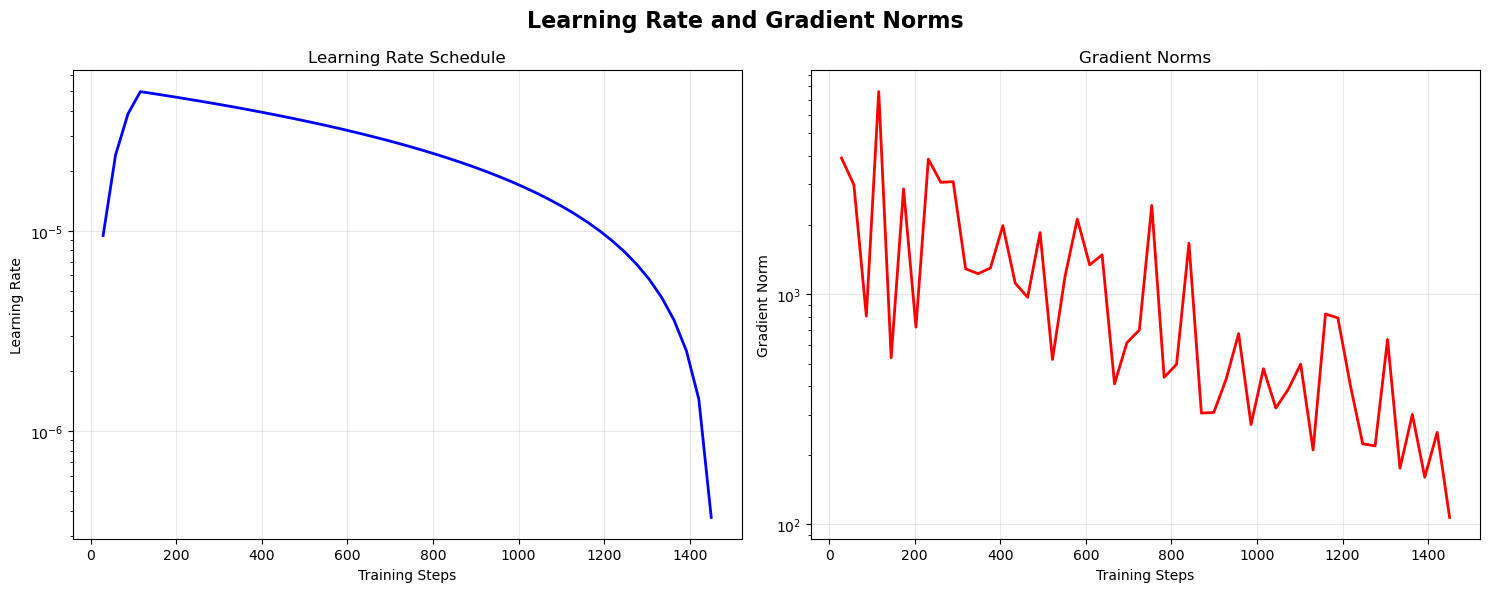

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Learning Rate and Gradient Norms', fontsize=16, fontweight='bold')

# learning rate
ax1.plot(data['train']['steps'], data['train']['learning_rates'], 'b-', linewidth=2)
ax1.set_xlabel('Training Steps')
ax1.set_ylabel('Learning Rate')
ax1.set_title('Learning Rate Schedule')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# no gradient norm
ax2.plot(data['train']['steps'], data['train']['grad_norms'], 'r-', linewidth=2)
ax2.set_xlabel('Training Steps')
ax2.set_ylabel('Gradient Norm')
ax2.set_title('Gradient Norms')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

# representation plot

### generate representation

In [9]:
from tqdm import tqdm
from transformers import AutoModel, AutoTokenizer
import torch
import numpy as np
import pandas as pd

In [10]:
def get_pooled_representations(model, tokenizer, sequences, pooling_method, device):
        """get pooled vector representations from sequences."""
        all_reps = []
        model.eval()
            
        with torch.no_grad():
            # (Note: This is not batched, but processes one by one. For large datasets, batching would be more efficient)
            for seq in tqdm(sequences, desc=f"Getting {pooling_method} representations"):
                inputs = tokenizer(seq, return_tensors="pt", padding=True, truncation=True, max_length=150).to(device)
                outputs = model(**inputs)
                last_hidden = outputs.last_hidden_state

                if pooling_method == "cls":
                    # use the vector of [CLS] token
                    pooled_rep = last_hidden[:, 0, :].squeeze(0)
                elif pooling_method == "mean":
                    # use the average of the vector of amino acid residues excluding special tokens
                    mask = inputs["attention_mask"].float()
                    mask[:, 0] = 0  # [CLS] token is masked
                    eos_indices = mask.sum(1).long() - 1
                    mask.scatter_(1, eos_indices.unsqueeze(1), 0)  # [EOS] token is masked
                    
                    emb_sum = (last_hidden * mask.unsqueeze(-1)).sum(1)
                    token_count = mask.sum(1, keepdim=True).clamp(min=1e-9)
                    pooled_rep = (emb_sum / token_count).squeeze(0)
                else:
                    raise ValueError(f"Unknown pooling method: {pooling_method}. Use 'mean' or 'cls'")
            
                all_reps.append(pooled_rep.cpu()) # move to CPU to save memory
                
        return torch.stack(all_reps, dim=0).to(device)

In [12]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
model_pretrained = AutoModel.from_pretrained("facebook/esm2_t6_8M_UR50D").to(device)
model_sft = AutoModel.from_pretrained("./models/esm2_8m_base-sft/encoder_lr_5e-5_batch_size_16_encoder_weight_decay_0.0001/encoder").to(device)
tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")

df = pd.read_csv('../data/nbthermo/vhh_tm_dataset.csv')
sequences = df["sequence_aho_ungapped"].tolist()

pooling_method = "mean"

pooled_representations_pretrained = get_pooled_representations(model_pretrained, tokenizer, sequences, "mean", "cuda:0")
pooled_representations_sft = get_pooled_representations(model_sft, tokenizer, sequences, "mean", "cuda:0")

print(f"number of sequences: {len(sequences)}")
print(f"dimension of pretrained features: {pooled_representations_pretrained.shape[1]}")
print(f"dimension of SFT features: {pooled_representations_sft.shape[1]}")

# torch.save(pooled_representations, "models/esm2_8m_base-sft_mean_ridge_tempro-vhh_lr_search/encoder_lr_1e-3_batch_size_16/checkpoint-100/pooled_representations.pt")

X_pretrained = pooled_representations_pretrained.cpu().numpy()
X_sft = pooled_representations_sft.cpu().numpy()

print(f"Pretrained pooled embedding: {X_pretrained.shape}")
print(f"SFT pooled embedding: {X_sft.shape}")

# load Tm data
y = df['tm'].values
print(f"data number: {len(y)}, Tm range: {y.min():.1f} - {y.max():.1f}")

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Getting mean representations: 100%|██████████| 567/567 [00:03<00:00, 158.19it/s]

number of sequences: 567
dimension of pretrained features: 320
dimension of SFT features: 320
Pretrained pooled embedding: (567, 320)
SFT pooled embedding: (567, 320)
data number: 567, Tm range: 43.0 - 98.2


## visualization of embeddings

In [16]:
import torch
from transformers import AutoTokenizer, AutoConfig, AutoModel
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

def t_sne_reduction(embeddings, n_components):
    # dimension reduction by t-SNE
    tsne = TSNE(n_components=2, perplexity=40, n_iter=3000, random_state=42)
    tsne_reduced = tsne.fit_transform(embeddings)
    print(f"t-SNE reduced shape: {tsne_reduced.shape}")
    
    df_tsne = pd.DataFrame(tsne_reduced, columns=["tsne1", "tsne2"])
    return df_tsne

# dimension reduction calculation
df_tsne_pretrained = t_sne_reduction(X_pretrained, 2)
df_tsne_SFT = t_sne_reduction(X_sft, 2)

# store t-SNE results in a dataframe and sort by Tm_value
df_tsne_pretrained["tm"] = y
df_tsne_pretrained = df_tsne_pretrained.sort_values(by="tm", ascending=True)  # Tm_value is sorted in ascending order

df_tsne_SFT["tm"] = y
df_tsne_SFT = df_tsne_SFT.sort_values(by="tm", ascending=True)  # Tm_value is sorted in ascending order

# check data
print("\nPretrained model t-SNE results (sorted by Tm_value):")
print(df_tsne_pretrained.head())

print("\nSFT model t-SNE results (sorted by Tm_value):")
print(df_tsne_SFT.head())

/home/taihei/.conda/envs/esm/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE reduced shape: (567, 2)


/home/taihei/.conda/envs/esm/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE reduced shape: (567, 2)

Pretrained model t-SNE results (sorted by Tm_value):
         tsne1      tsne2     tm
509  -0.008051 -21.900862  43.00
334  -0.008051 -21.900862  43.00
213   4.533392   9.849949  43.00
198  21.546724  -7.612597  43.08
194  21.712521  -6.865038  43.38

SFT model t-SNE results (sorted by Tm_value):
         tsne1     tsne2     tm
509  44.225163  1.127913  43.00
334  44.225163  1.127913  43.00
213  44.557545  2.025350  43.00
198  43.711765  3.616858  43.08
194  43.440010  3.812478  43.38


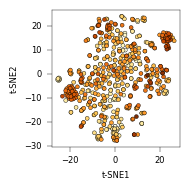

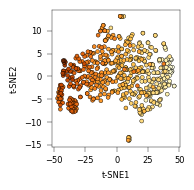

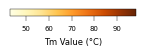

In [14]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os

# ------------------------------
# visualization of dimension reduction results (no colorbar)
# ------------------------------

# setting for color map
norm = plt.Normalize(df_tsne_pretrained["tm"].min(), df_tsne_pretrained["tm"].max())
cmap = cm.YlOrBr

# common setting for frame
edge_color = 'black'
line_width = 0.3

# create save directory
save_dir = 'figure'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 1) plot of pretrained model encoder (no colorbar)
fig1, ax1 = plt.subplots(1, 1, figsize=(2, 2))
sc1 = ax1.scatter(
    df_tsne_pretrained["tsne1"], 
    df_tsne_pretrained["tsne2"],
    c=df_tsne_pretrained['tm'], 
    cmap=cmap, 
    s=8, 
    norm=norm, 
    edgecolors='black',
    linewidth=0.3
)
ax1.set_xlabel("t-SNE1", fontsize=6)
ax1.set_ylabel("t-SNE2", fontsize=6)
ax1.tick_params(axis='both', width=line_width, labelsize=6)
ax1.grid(False)
ax1.spines['top'].set_linewidth(line_width)
ax1.spines['bottom'].set_linewidth(line_width)
ax1.spines['left'].set_linewidth(line_width)
ax1.spines['right'].set_linewidth(line_width)
ax1.spines['top'].set_color(edge_color)
ax1.spines['bottom'].set_color(edge_color)
ax1.spines['left'].set_color(edge_color)
ax1.spines['right'].set_color(edge_color)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'embedding_plot_pretrained.png'), dpi=350, format="png", bbox_inches='tight')
plt.show()

# 2) plot of SFT model encoder (no colorbar)
fig2, ax2 = plt.subplots(1, 1, figsize=(2, 2))
sc2 = ax2.scatter(
    df_tsne_SFT["tsne1"], 
    df_tsne_SFT["tsne2"],
    c=df_tsne_SFT['tm'], 
    cmap=cmap, 
    s=8, 
    norm=norm, 
    edgecolors='black',
    linewidth=0.3
)
ax2.set_xlabel("t-SNE1", fontsize=6)
ax2.set_ylabel("t-SNE2", fontsize=6)
ax2.tick_params(axis='both', width=line_width, labelsize=6)
ax2.grid(False)
ax2.spines['top'].set_linewidth(line_width)
ax2.spines['bottom'].set_linewidth(line_width)
ax2.spines['left'].set_linewidth(line_width)
ax2.spines['right'].set_linewidth(line_width)
ax2.spines['top'].set_color(edge_color)
ax2.spines['bottom'].set_color(edge_color)
ax2.spines['left'].set_color(edge_color)
ax2.spines['right'].set_color(edge_color)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'embedding_plot_sft.png'), dpi=350, format="png", bbox_inches='tight')
plt.show()

# 3) colorbar
fig3, ax3 = plt.subplots(1, 1, figsize=(3, 1))
# create dummy scatter plot (only for colorbar)
dummy_scatter = ax3.scatter([], [], c=[], cmap=cmap, norm=norm)
ax3.set_visible(False)  # hide axis

# display colorbar
cbar3 = fig3.colorbar(dummy_scatter, ax=ax3, orientation='horizontal', shrink=0.8, pad=0.1)
cbar3.set_label('Tm Value (°C)', fontsize=6)
cbar3.ax.tick_params(width=line_width, labelsize=5)
cbar3.outline.set_linewidth(line_width)
cbar3.outline.set_edgecolor(edge_color)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'embedding_plot_colorbar.png'), dpi=350, format="png", bbox_inches='tight')
plt.show()

Pearson correlation coefficient between t-SNE1 and Tm: -0.934 (p=2.66e-255)


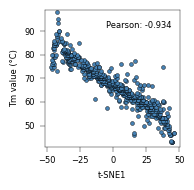

In [15]:
# calculate Pearson correlation coefficient
from scipy.stats import pearsonr
pearson_corr, pearson_p = pearsonr(df_tsne_SFT["tsne1"], df_tsne_SFT["tm"])
print(f"Pearson correlation coefficient between t-SNE1 and Tm: {pearson_corr:.3f} (p={pearson_p:.3g})")

# plot of scatter plot to check the correlation between t-SNE1 and Tm
fig, ax = plt.subplots(figsize=(2, 2))
ax.scatter(df_tsne_SFT["tsne1"], df_tsne_SFT["tm"], s=8, color='steelblue', edgecolors='black', linewidth=0.3)
ax.set_xlabel("t-SNE1", fontsize=6)
ax.set_ylabel("Tm value (°C)", fontsize=6)
ax.tick_params(axis='both', width=0.3, labelsize=6)
ax.grid(False)

# set plot range (fixed range to 30-100)
plot_min, plot_max = 41, 99
ax.set_ylim(plot_min, plot_max)

ax.spines['top'].set_linewidth(0.3)
ax.spines['bottom'].set_linewidth(0.3)
ax.spines['left'].set_linewidth(0.3)
ax.spines['right'].set_linewidth(0.3)

# display evaluation metrics on the plot
stats_text = (f"Pearson: {pearson_corr:.3f}")

ax.text(0.45, 0.92, stats_text,
        transform=ax.transAxes,
        fontsize=6,
        verticalalignment="top",
        linespacing=1.5)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'embedding_plot_sft_correlation.png'), dpi=350, format="png", bbox_inches='tight')
plt.show()

# Performance evaluation of Tm prediction model

## pretrained(ridgecv)

In [17]:
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import MaxAbsScaler, RobustScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import make_scorer, mean_squared_error, r2_score, mean_absolute_error
import numpy as np
from sklearn.model_selection import KFold
from scipy.stats import pearsonr

# split data
X_pretrained_train, X_pretrained_test, y_train, y_test = train_test_split(X_pretrained, y, test_size=0.2, random_state=42)

# feature standardization
scaler_pretrained = MaxAbsScaler()

X_pretrained_train_scaled = scaler_pretrained.fit_transform(X_pretrained_train)
X_pretrained_test_scaled = scaler_pretrained.transform(X_pretrained_test)

# learn RidgeCV
alphas = np.logspace(-1, 4, 30)

ridgecv_pretrained = RidgeCV(alphas=alphas, cv=10, scoring="neg_root_mean_squared_error")

ridgecv_pretrained.fit(X_pretrained_train_scaled, y_train)

print(f"Pretrained: Optimal α={ridgecv_pretrained.alpha_}")

# performance evaluation of model
y_pred_pretrained = ridgecv_pretrained.predict(X_pretrained_test_scaled)

def evaluate_model(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    pearson, _ = pearsonr(y_true, y_pred)
    print(f"{name}: RMSE={rmse:.3f}, R²={r2:.3f}, MAE={mae:.3f}, Pearson={pearson:.3f}")
    return {'rmse': rmse, 'r2': r2, 'mae': mae, 'pearson': pearson}

# performance evaluation
print("=== performance comparison ===")
pretrained_metrics = evaluate_model(y_test, y_pred_pretrained, "Pretrained")


Pretrained: Optimal α=1.0826367338740546
=== performance comparison ===
Pretrained: RMSE=6.621, R²=0.609, MAE=4.947, Pearson=0.787


## Supervised_finetuning (load head parameter)

In [20]:
from safetensors.torch import load_file
import torch
import torch.nn as nn
from pathlib import Path
import numpy as np

# split data
X_sft_train, X_sft_test, y_train, y_test = train_test_split(X_sft, y, test_size=0.2, random_state=42)

# load head parameter
path = '/data3/taihei/matsunaga-repos/vhh_up/PLM/models/best_models/esm2_8m_base-sft_251201/encoder_lr_5e-5_batch_size_16_encoder_weight_decay_0.0001/head/head_weights.safetensors'
head_weights = load_file(Path(path))

print("loaded head parameter keys:", list(head_weights.keys()))
print("head parameter shapes:")
for key, value in head_weights.items():
    print(f"  {key}: {value.shape}")

# build head model based on head parameter structure
class SimpleHead(nn.Module):
    def __init__(self, input_dim, output_dim=1):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        
    def forward(self, x):
        return self.linear(x)

# estimate input dimension (from head parameter shape)
if 'weight' in head_weights and 'bias' in head_weights:
    # weight.shape = [1, 320] なので input_dim=320, output_dim=1
    input_dim = head_weights['weight'].shape[1]  # 320
    output_dim = head_weights['weight'].shape[0]  # 1
    head = SimpleHead(input_dim, output_dim)
    
    # set weight manually
    with torch.no_grad():
        head.linear.weight.data = head_weights['weight']
        head.linear.bias.data = head_weights['bias']
    
    head.eval()
    
    # convert X_sft to PyTorch tensor
    X_sft_test_tensor = torch.tensor(X_sft_test, dtype=torch.float32)
    
    # execute prediction
    with torch.no_grad():
        y_pred_sft = head(X_sft_test_tensor).squeeze().numpy()
    
    # performance evaluation
    print("=== performance comparison ===")
    sft_metrics = evaluate_model(y_test, y_pred_sft, "SFT")
    
else:
    print("The structure of the weight is different from the expected structure.")
    print("Available weights:", head_weights.keys())

loaded head parameter keys: ['bias', 'weight']
head parameter shapes:
  bias: torch.Size([1])
  weight: torch.Size([1, 320])
=== performance comparison ===
SFT: RMSE=5.402, R²=0.739, MAE=3.934, Pearson=0.865


/home/taihei/.conda/envs/esm/lib/python3.11/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()


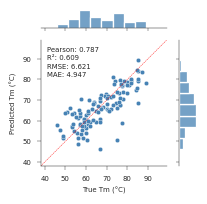

/home/taihei/.conda/envs/esm/lib/python3.11/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()


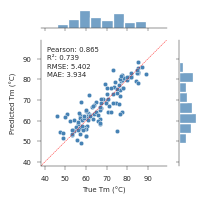

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

def create_joint_plot(tm_values, predictions, metrics,
                     title=None,
                     title_size=8,
                     figsize=(2, 2),      # 図のサイズ
                     scatter_size=10,     # 散布図の点のサイズ
                     tick_size=5,         # 軸目盛りのフォントサイズ
                     label_size=6,        # 軸ラベルのフォントサイズ
                     stats_size=6,        # 統計情報のフォントサイズ
                     linespacing=1.5):     # 統計情報の行間

    rmse = metrics['rmse']
    r2 = metrics['r2']
    mae = metrics['mae']
    pearson = metrics['pearson']

    sns.set_style("whitegrid", {"grid.color": "0.9"})
    BORDER_COLOR = 'black'
    line_width = 0.3

    jp = sns.jointplot(x=tm_values, y=predictions, 
                      kind="scatter", 
                      height=figsize[0], 
                      color="steelblue", 
                      edgecolor="w",
                      s=scatter_size)    

    jp.ax_marg_x.set_position([0.05, 0.82, 0.7, 0.1]) 
    jp.ax_marg_y.set_position([0.82, 0.05, 0.1, 0.7]) 
    jp.ax_joint.set_position([0.05, 0.05, 0.7, 0.7]) 

    plot_min, plot_max = 38, 99
    jp.ax_joint.set_xlim(plot_min, plot_max)
    jp.ax_joint.set_ylim(plot_min, plot_max)

    for spine in jp.ax_joint.spines.values():
        if spine in [jp.ax_joint.spines['top'], jp.ax_joint.spines['right']]:
            spine.set_visible(False)
        else: 
            spine.set_visible(True)
            spine.set_color(BORDER_COLOR)
            spine.set_linewidth(line_width)

    for spine in jp.ax_marg_x.spines.values():
        if spine in [jp.ax_marg_x.spines['top'], jp.ax_marg_x.spines['left'], jp.ax_marg_x.spines['right']]:
            spine.set_visible(False)
        else:  
            spine.set_visible(True)
            spine.set_color(BORDER_COLOR)
            spine.set_linewidth(line_width)
    jp.ax_marg_x.grid(False)
    jp.ax_marg_x.tick_params(axis='x', direction="out", bottom=True, length=2, width=line_width)

    for spine in jp.ax_marg_y.spines.values():
        if spine in [jp.ax_marg_y.spines['top'], jp.ax_marg_y.spines['bottom'], jp.ax_marg_y.spines['right']]:
            spine.set_visible(False)
        else:  
            spine.set_visible(True)
            spine.set_color(BORDER_COLOR)
            spine.set_linewidth(line_width)
    jp.ax_marg_y.grid(False)
    jp.ax_marg_y.tick_params(axis='y', direction="out", left=True, length=2, width=line_width)
    
    jp.ax_joint.set_xticks([40, 50, 60, 70, 80, 90])
    jp.ax_joint.tick_params(axis='both', direction="out", bottom=True, left=True, length=3, width=line_width, labelsize=tick_size)

    jp.ax_joint.grid(False)

    jp.ax_joint.plot([plot_min, plot_max], [plot_min, plot_max], "r--", lw=0.3)

    jp.set_axis_labels("True Tm (°C)", "Predicted Tm (°C)", fontsize=label_size)

    if title:
        jp.fig.suptitle(title, fontsize=title_size)

    stats_text = (f"Pearson: {pearson:.3f}\n"
                 f"R²: {r2:.3f}\n"
                 f"RMSE: {rmse:.3f}\n"
                 f"MAE: {mae:.3f}")

    jp.ax_joint.text(0.05, 0.95, stats_text,
                     transform=jp.ax_joint.transAxes,
                     fontsize=stats_size,
                     verticalalignment="top",
                     linespacing=linespacing,
                     bbox=dict(boxstyle="round",
                              facecolor="white",
                              alpha=0.5))
    
    return jp

def save_plot(jp, filename='evaluation_tm_supervised.png', dpi=350):
    save_dir = 'figure'
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    save_path = os.path.join(save_dir, filename)
    jp.savefig(save_path, dpi=dpi, format="png")

jp_pretrained = create_joint_plot(y_test,
                          y_pred_pretrained,
                          pretrained_metrics,
                          figsize=(1.8, 1.8),
                          scatter_size=10,
                          tick_size=5,
                          label_size=5,
                          stats_size=5,
                          linespacing=1.5)

save_plot(jp_pretrained, filename='evaluation_tm_Pre-trained.png', dpi=350)
plt.show()

jp_sft = create_joint_plot(y_test,
                          y_pred_sft,
                          sft_metrics,
                          figsize=(1.8, 1.8),
                          scatter_size=10,
                          tick_size=5,
                          label_size=5,
                          stats_size=5,
                          linespacing=1.5)

save_plot(jp_sft, filename='evaluation_tm_SFT.png', dpi=350)
plt.show()


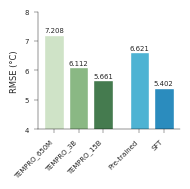

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import os

models_tempro = ["TEMPRO_650M", "TEMPRO_3B", "TEMPRO_15B"]
rmse_tempro = [7.208, 6.112, 5.661]
models_other = ["Pre-trained", "SFT"]
rmse_other = [6.621, 5.402]

x_tempro = np.arange(len(models_tempro))
x_other = np.arange(len(models_other)) + len(models_tempro) + 0.5 

fig, ax = plt.subplots(figsize=(2, 2))

BORDER_COLOR = 'black'

line_width = 0.3

bars1 = ax.bar(x_tempro, rmse_tempro, color=["#CFE3C7", "#8AB884", "#457B4F"])
bars2 = ax.bar(x_other, rmse_other, color=["#4eb3d3", "#2b8cbe"])

for bar, val in zip(bars1 + bars2, rmse_tempro + rmse_other):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05, f"{val:.3f}",
            ha='center', va='bottom', fontsize=5)

ax.set_ylabel("RMSE (°C)", fontsize=6)
ax.set_ylim(4, max(rmse_tempro + rmse_other) * 1.1)

ax.set_yticks(np.arange(4.0, np.ceil(max(rmse_tempro + rmse_other))*1.1, 1.0))
ax.tick_params(axis='both', direction="out", bottom=True, left=True, length=3, width=line_width, labelsize=5)
ax.set_xticks(list(x_tempro) + list(x_other))
ax.set_xticklabels(models_tempro + models_other, rotation=45, ha='right', fontsize=5)
ax.grid(False)

ax.spines['bottom'].set_color(BORDER_COLOR)
ax.spines['left'].set_color(BORDER_COLOR)
ax.spines['bottom'].set_linewidth(line_width)
ax.spines['left'].set_linewidth(line_width)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

save_dir = 'figure'
save_path = os.path.join(save_dir, 'rmse_by_model.png')
plt.tight_layout()
plt.savefig(save_path, dpi=350, format="png")
plt.show()
